# Welcome to the HydraNet Home Robot Workshop 🐸🐸🐸

In this workshop, you're going to learn how to train a Neural Network that does **real-time semantic segmentation and monocular depth prediction**.

![](https://d3i71xaburhd42.cloudfront.net/435d4b5c30f10753d277848a17baddebd98d3c31/2-Figure1-1.png)

The Model is [a Multi-Task Learning algorithm designed by Vladimir Nekrasov](https://arxiv.org/pdf/1809.04766.pdf). The entire work is based on the **DenseTorch Library**, that you can find and use [here](https://github.com/DrSleep/DenseTorch). <p>

**A note —** This notebook is adapting the Library with express authorization from the author for educational purpose.

## Home Robot 🤖
* In the previous workshop of the course, you learned how to design the model shown above, and to run it on the KITTI Dataset using pretrained weights. The **KITTI Dataset only has 200 examples of segmentation**. Therefore, the authors used a technique called Knowledge Distillation and finetuned using the Cityscape dataset.<p>

* 👉 In our case, we'll use another dataset called the [NYUDv2 Dataset](https://cs.nyu.edu/~silberman/datasets/nyu_depth_v2.html). **It contains 1449 annotated images for depth and segmentation**, which makes our life much simpler. —— Since this is an indoor dataset, we'll turn this project into a Home Robot Workshop!

#1 — Imports

We're going to import:
*   The **Data from our previous notebook** (trained model, cmaps, ...)
*   The **NYUD Dataset**, along with helper files, ground truth examples, and train/test split files




In [ ]:
!wget https://hydranets-data.s3.eu-west-3.amazonaws.com/hydranets-data-2.zip && unzip -q hydranets-data-2.zip && mv hydranets-data-2/* . && rm hydranets-data-2.zip && rm -rf hydranets-data-2

In [136]:
%matplotlib inline
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# 1 — Dataset
Let's begin with importing our data, and visualizing it.

## Load and Visualize the Dataset

In [137]:
import glob

depth = sorted(glob.glob("./nyud/depth/*.png"))#TODO: Load the Path
seg = sorted(glob.glob("./nyud/masks/*.png"))#TODO: Load the Path
images = sorted(glob.glob("./nyud/rgb/*.png"))#TODO: Load the Path

In [138]:
depth

['./nyud/depth/000001.png',
 './nyud/depth/000002.png',
 './nyud/depth/000003.png',
 './nyud/depth/000004.png',
 './nyud/depth/000005.png',
 './nyud/depth/000006.png',
 './nyud/depth/000007.png',
 './nyud/depth/000008.png',
 './nyud/depth/000009.png',
 './nyud/depth/000010.png',
 './nyud/depth/000011.png',
 './nyud/depth/000012.png',
 './nyud/depth/000013.png',
 './nyud/depth/000014.png',
 './nyud/depth/000015.png',
 './nyud/depth/000016.png',
 './nyud/depth/000017.png',
 './nyud/depth/000018.png',
 './nyud/depth/000019.png',
 './nyud/depth/000020.png',
 './nyud/depth/000021.png',
 './nyud/depth/000022.png',
 './nyud/depth/000023.png',
 './nyud/depth/000024.png',
 './nyud/depth/000025.png',
 './nyud/depth/000026.png',
 './nyud/depth/000027.png',
 './nyud/depth/000028.png',
 './nyud/depth/000029.png',
 './nyud/depth/000030.png',
 './nyud/depth/000031.png',
 './nyud/depth/000032.png',
 './nyud/depth/000033.png',
 './nyud/depth/000034.png',
 './nyud/depth/000035.png',
 './nyud/depth/00003

In [139]:
print(len(images))
print(len(depth))
print(len(seg))

1449
1449
1449


Since our dataset is a bit "special", we'll need a Color Map to read it.

In [140]:
CMAP = np.load('cmap_nyud.npy')
print(len(CMAP))

256


In [141]:
np.shape(CMAP)

(256, 3)

In [142]:
CMAP

array([[  0,   0,   0],
       [128,   0,   0],
       [  0, 128,   0],
       [128, 128,   0],
       [  0,   0, 128],
       [128,   0, 128],
       [  0, 128, 128],
       [128, 128, 128],
       [ 64,   0,   0],
       [192,   0,   0],
       [ 64, 128,   0],
       [192, 128,   0],
       [ 64,   0, 128],
       [192,   0, 128],
       [ 64, 128, 128],
       [192, 128, 128],
       [  0,  64,   0],
       [128,  64,   0],
       [  0, 192,   0],
       [128, 192,   0],
       [  0,  64, 128],
       [128,  64, 128],
       [  0, 192, 128],
       [128, 192, 128],
       [ 64,  64,   0],
       [192,  64,   0],
       [ 64, 192,   0],
       [192, 192,   0],
       [ 64,  64, 128],
       [192,  64, 128],
       [ 64, 192, 128],
       [192, 192, 128],
       [  0,   0,  64],
       [128,   0,  64],
       [  0, 128,  64],
       [128, 128,  64],
       [  0,   0, 192],
       [128,   0, 192],
       [  0, 128, 192],
       [128, 128, 192],
       [ 64,   0,  64],
       [192,   0

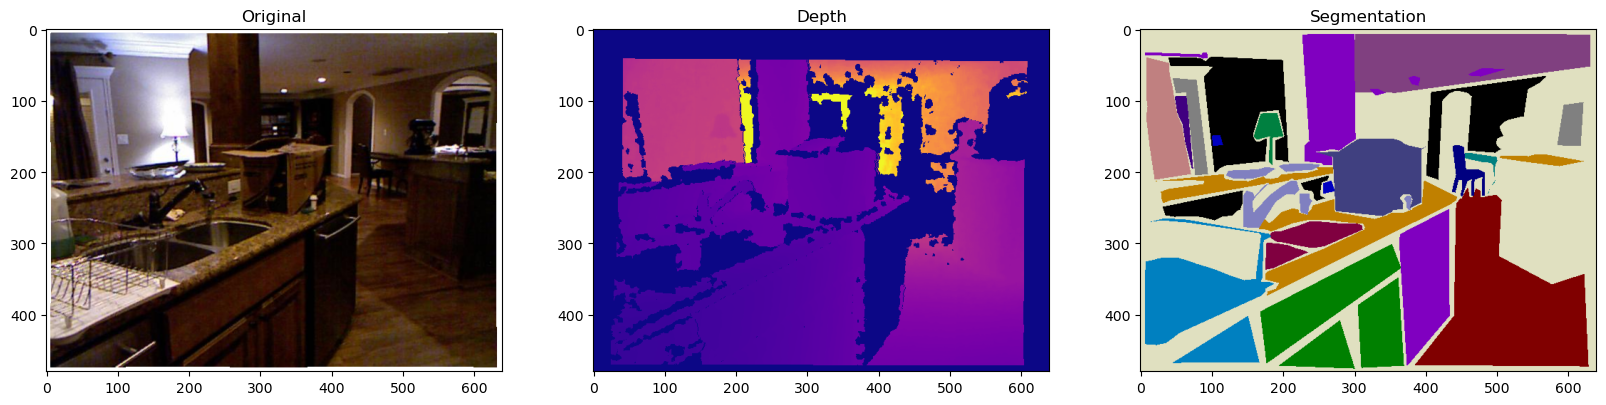

In [143]:
idx = np.random.randint(0,len(seg))

f, (ax0, ax1, ax2) = plt.subplots(1,3, figsize=(20,40))
ax0.imshow(np.array(Image.open(images[idx])))
ax0.set_title("Original")
ax1.imshow(np.array(Image.open(depth[idx])), cmap="plasma")
ax1.set_title("Depth")
ax2.imshow(CMAP[np.array(Image.open(seg[idx]))])
ax2.set_title("Segmentation")
plt.show()

In [144]:
print(np.unique(np.array(Image.open(seg[idx]))))
print(len(np.unique(np.array(Image.open(seg[idx])))))

[  0   1   2   4   6   7  11  12  15  21  28  33  34  36  37  38  39 255]
18


In [145]:
np.shape(CMAP[np.array(Image.open(seg[idx]))])

(480, 640, 3)

In [146]:
np.shape(np.array(Image.open(images[idx])))

(480, 640, 3)

## Getting the DataLoader

When training a model, 2 elements are going to be very important (compared to the last workshop):

*   The Dataset
*   The Training Loop, Loss, etc

We already know how to design the model that does join depth and segmentation, so we only need to know how to train it!

In [147]:
data_file = "train_list_depth.txt"

with open(data_file, "rb") as f:
    datalist = f.readlines()
datalist = [x.decode("utf-8").strip("\n").split("\t") for x in datalist]

root_dir = "/nyud"
masks_names = ("segm", "depth")

print(datalist[0])
print(datalist[0][0])

['rgb/000003.png', 'masks/000003.png', 'depth/000003.png']
rgb/000003.png


In [148]:
import os
abs_paths = [os.path.join("nyud", rpath) for rpath in datalist[0]]
abs_paths

['nyud/rgb/000003.png', 'nyud/masks/000003.png', 'nyud/depth/000003.png']

img_arr.shape = (480, 640, 3)


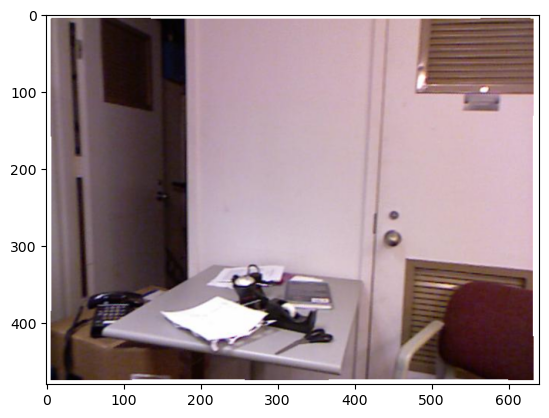

In [149]:
img_arr = np.array(Image.open(abs_paths[0]))#TODO: Load an RGB Image
img_h, img_w, _ = np.shape(img_arr)

print(f"img_arr.shape = {np.shape(img_arr)}")
plt.imshow(img_arr)
plt.show()

np.shape(mask) = (480, 640)


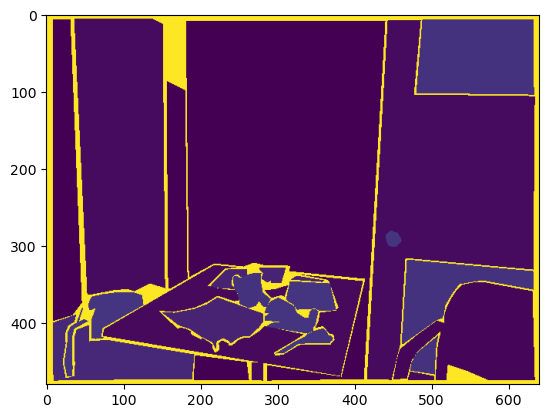

np.shape(mask) = (480, 640)


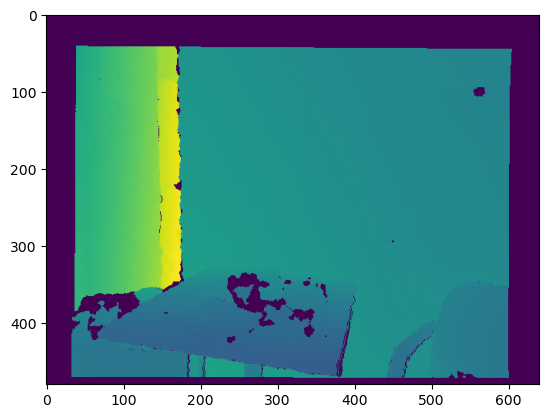

In [150]:
masks_names = ("segm", "depth")

for mask_name, mask_path in zip(masks_names, abs_paths[1:]):
    mask = np.array(Image.open(mask_path))
    print(f"np.shape(mask) = {np.shape(mask)}")
    plt.imshow(mask)
    plt.show()

In [151]:
from torch.utils.data import Dataset

class HydranetDataset(Dataset):

    def __init__(self, data_file, transform=None):
        with open(data_file, "rb") as f:
            datalist = f.readlines()
        self.datalist = [x.decode("utf-8").strip("\n").split("\t") for x in datalist]
        self.root_dir = "nyud"
        self.transform = transform
        self.masks_names = ("segm", "depth")

    def __len__(self):
        return len(self.datalist)

    def __getitem__(self, idx):
        abs_paths = [os.path.join(self.root_dir, rpath) for rpath in self.datalist[idx]] # Will output list of nyud/*/00000.png
        sample = {}
        sample["image"] = np.array(Image.open(abs_paths[0]))#TODO: Copy/Paste your loaded code

        for mask_name, mask_path in zip(self.masks_names, abs_paths[1:]):
            sample[f"{mask_name}"] = np.array(Image.open(mask_path))

        if self.transform:
            sample["names"] = self.masks_names
            sample = self.transform(sample)
            # the names key can be removed by the transformation
            if "names" in sample:
                del sample["names"]
        return sample

### Normalization — Will be common to all images


In [152]:
from utils import Normalise, RandomCrop, ToTensor, RandomMirror
import torchvision.transforms as transforms

In [153]:
img_scale = 1.0 / 255
depth_scale = 5000.0

img_mean = np.array([0.485, 0.456, 0.406])
img_std = np.array([0.229, 0.224, 0.225])

normalise_params = [img_scale, img_mean.reshape((1, 1, 3)), img_std.reshape((1, 1, 3)), depth_scale,]

transform_common = [Normalise(*normalise_params), ToTensor()]

### Transforms

In [154]:
#crop_size = 400
crop_size = min(img_w, img_h)
transform_train = transforms.Compose([RandomMirror(), RandomCrop(crop_size)] + transform_common)
transform_val = transforms.Compose(transform_common)

### DataLoader

In [155]:
train_batch_size = 4
val_batch_size = 4
train_file = "train_list_depth.txt"
val_file = "val_list_depth.txt"

In [156]:
from torch.utils.data import DataLoader

#TRAIN DATALOADER
trainloader = DataLoader(HydranetDataset(train_file, transform_train),
                          batch_size=train_batch_size,
                          shuffle=True,
                          num_workers=4,
                          pin_memory=True,
                          drop_last=False)#TODO: Call the Train DataLoader

# VALIDATION DATALOADER
valloader = DataLoader(HydranetDataset(val_file, transform_val),
                       batch_size=val_batch_size,
                       shuffle=True,
                       num_workers=4,
                       pin_memory=True,
                       drop_last=False)#TODO: Call the Validation DataLoader

# 2 — Creating the HydraNet
We now have 2 DataLoaders: one for training, and one for validation/test. <p>

In the next step, we're going to define our model, following the paper [Real-Time Joint Semantic Segmentation and Depth Estimation Using Asymmetric Annotations](https://arxiv.org/pdf/1809.04766.pdf) —— If you haven't read it yet, now is the time.
<p>

> ![](https://d3i71xaburhd42.cloudfront.net/435d4b5c30f10753d277848a17baddebd98d3c31/2-Figure1-1.png)

Our model takes an input RGB image, make it go through an encoder, a lightweight refinenet decoder, and then has 2 heads, one for each task.<p>
Things to note:
* The only **convolutions** we'll need will be 3x3 and 1x1
* We also need a **MaxPooling 5x5**
* **CRP-Blocks** are implemented as Skip-Connection Operations
* **Each Head is made of a 1x1 convolution followed by a 3x3 convolution**, only the data and the loss change there


## Building the Encoder — A MobileNetv2
![](https://iq.opengenus.org/content/images/2020/11/conv_mobilenet_v2.jpg)

In [157]:
def conv3x3(in_channels, out_channels, stride=1, dilation=1, groups=1, bias=False):
    """3x3 Convolution: Depthwise:
    https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html
    """
    return nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=dilation, dilation=dilation, bias=bias, groups=groups)

In [158]:
def conv1x1(in_channels, out_channels, stride=1, groups=1, bias=False,):
    "1x1 Convolution: Pointwise"
    return nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, padding=0, bias=bias, groups=groups)

In [159]:
def batchnorm(num_features):
    """
    https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html
    """
    return nn.BatchNorm2d(num_features, affine=True, eps=1e-5, momentum=0.1)

In [160]:
def convbnrelu(in_channels, out_channels, kernel_size, stride=1, groups=1, act=True):
    "conv-batchnorm-relu"
    if act:
        return nn.Sequential(nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=int(kernel_size / 2.), groups=groups, bias=False),
                             batchnorm(out_channels),
                             nn.ReLU6(inplace=True))
    else:
        return nn.Sequential(nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=int(kernel_size / 2.), groups=groups, bias=False),
                             batchnorm(out_channels))

In [161]:
class InvertedResidualBlock(nn.Module):
    """Inverted Residual Block from https://arxiv.org/abs/1801.04381"""
    def __init__(self, in_planes, out_planes, expansion_factor, stride=1):
        super().__init__() # Python 3
        intermed_planes = in_planes * expansion_factor
        self.residual = (in_planes == out_planes) and (stride == 1) # Boolean/Condition
        self.output = nn.Sequential(convbnrelu(in_planes, intermed_planes, 1),
                                    convbnrelu(intermed_planes, intermed_planes, 3, stride=stride, groups=intermed_planes),
                                    convbnrelu(intermed_planes, out_planes, 1, act=False))

    def forward(self, x):
        #residual = x
        out = self.output(x)
        if self.residual:
            return (out + x)#+residual
        else:
            return out

In [162]:
class MobileNetv2(nn.Module):
    def __init__(self, return_idx=[6]):
        super().__init__()
        # expansion rate, output channels, number of repeats, stride
        self.mobilenet_config = [
        [1, 16, 1, 1],
        [6, 24, 2, 2],
        [6, 32, 3, 2],
        [6, 64, 4, 2],
        [6, 96, 3, 1],
        [6, 160, 3, 2],
        [6, 320, 1, 1],
        ]
        self.in_channels = 32  # number of input channels
        self.num_layers = len(self.mobilenet_config)
        self.layer1 = convbnrelu(3, self.in_channels, kernel_size=3, stride=2)

        self.return_idx = [1, 2, 3, 4, 5, 6]
        #self.return_idx = make_list(return_idx)

        c_layer = 2
        for t, c, n, s in self.mobilenet_config:
            layers = []
            for idx in range(n):
                layers.append(InvertedResidualBlock(self.in_channels,c,expansion_factor=t,stride=s if idx == 0 else 1,))
                self.in_channels = c
            setattr(self, "layer{}".format(c_layer), nn.Sequential(*layers))
            c_layer += 1

        self._out_c = [self.mobilenet_config[idx][1] for idx in self.return_idx] # Output: [24, 32, 64, 96, 160, 320]

    def forward(self, x):
        outs = []
        x = self.layer1(x)
        outs.append(self.layer2(x))  # 16, x / 2
        outs.append(self.layer3(outs[-1]))  # 24, x / 4
        outs.append(self.layer4(outs[-1]))  # 32, x / 8
        outs.append(self.layer5(outs[-1]))  # 64, x / 16
        outs.append(self.layer6(outs[-1]))  # 96, x / 16
        outs.append(self.layer7(outs[-1]))  # 160, x / 32
        outs.append(self.layer8(outs[-1]))  # 320, x / 32
        return [outs[idx] for idx in self.return_idx]

In [163]:
checkpoint = torch.load("mobilenetv2-e6e8dd43.pth")
print(checkpoint.keys())

/tmp/ipykernel_72076/2523803628.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("mobilenetv2-e6e8dd43.pth")


odict_keys(['layer1.0.weight', 'layer1.1.weight', 'layer1.1.bias', 'layer1.1.running_mean', 'layer1.1.running_var', 'layer1.1.num_batches_tracked', 'layer2.0.output.0.0.weight', 'layer2.0.output.0.1.weight', 'layer2.0.output.0.1.bias', 'layer2.0.output.0.1.running_mean', 'layer2.0.output.0.1.running_var', 'layer2.0.output.0.1.num_batches_tracked', 'layer2.0.output.1.0.weight', 'layer2.0.output.1.1.weight', 'layer2.0.output.1.1.bias', 'layer2.0.output.1.1.running_mean', 'layer2.0.output.1.1.running_var', 'layer2.0.output.1.1.num_batches_tracked', 'layer2.0.output.2.0.weight', 'layer2.0.output.2.1.weight', 'layer2.0.output.2.1.bias', 'layer2.0.output.2.1.running_mean', 'layer2.0.output.2.1.running_var', 'layer2.0.output.2.1.num_batches_tracked', 'layer3.0.output.0.0.weight', 'layer3.0.output.0.1.weight', 'layer3.0.output.0.1.bias', 'layer3.0.output.0.1.running_mean', 'layer3.0.output.0.1.running_var', 'layer3.0.output.0.1.num_batches_tracked', 'layer3.0.output.1.0.weight', 'layer3.0.outp

In [164]:
encoder = MobileNetv2()
encoder.load_state_dict(torch.load("mobilenetv2-e6e8dd43.pth"))

/tmp/ipykernel_72076/4003048153.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  encoder.load_state_dict(torch.load("mobilenetv2-e6e8dd43.pth"))


<All keys matched successfully>

In [165]:
print(encoder)

MobileNetv2(
  (layer1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU6(inplace=True)
  )
  (layer2): Sequential(
    (0): InvertedResidualBlock(
      (output): Sequential(
        (0): Sequential(
          (0): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Sequential(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (2): Sequential(
          (0): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, af

## Building the Decoder - A Multi-Task Lighweight RefineNet
Paper: https://arxiv.org/pdf/1810.03272.pdf
![](https://drsleep.github.io/images/rf_arch.png)

In [166]:
def make_list(x):
    """Returns the given input as a list."""
    if isinstance(x, list):
        return x
    elif isinstance(x, tuple):
        return list(x)
    else:
        return [x]

In [167]:
class CRPBlock(nn.Module):
    """CRP definition"""
    def __init__(self, in_planes, out_planes, n_stages, groups=False):
        super().__init__()
        for i in range(n_stages):
            if groups:
                setattr(self, '{}_{}'.format(i + 1, 'outvar_dimred'),
                    conv1x1(in_planes if (i == 0) else out_planes,
                            out_planes, stride=1,
                            bias=False, groups= in_planes if i==0 else out_planes))
            else:
                setattr(self, '{}_{}'.format(i + 1, 'outvar_dimred'),
                    conv1x1(in_planes if (i == 0) else out_planes,
                            out_planes, stride=1,
                            bias=False, groups=1))

        self.stride = 1
        self.n_stages = n_stages
        self.maxpool = nn.MaxPool2d(kernel_size=5, stride=1, padding=2)

    def forward(self, x):
        top = x
        for i in range(self.n_stages):
            top = self.maxpool(top)
            top = getattr(self, '{}_{}'.format(i + 1, 'outvar_dimred'))(top)
            x = top + x
        return x

In [168]:
class MTLWRefineNet(nn.Module):
    def __init__(self, input_sizes, num_classes, agg_size=256, n_crp=4):
        super().__init__()

        stem_convs = nn.ModuleList()
        crp_blocks = nn.ModuleList()
        adapt_convs = nn.ModuleList()
        heads = nn.ModuleList()

        # Reverse since we recover information from the end
        input_sizes = list(reversed((input_sizes)))

        # No reverse for collapse indices is needed
        self.collapse_ind = [[0, 1], [2, 3], 4, 5]

        groups = [False] * len(self.collapse_ind)
        groups[-1] = True

        for size in input_sizes:
            stem_convs.append(conv1x1(size, agg_size, bias=False))

        for group in groups:
            crp_blocks.append(self._make_crp(agg_size, agg_size, n_crp, group))
            adapt_convs.append(conv1x1(agg_size, agg_size, bias=False))

        self.stem_convs = stem_convs
        self.crp_blocks = crp_blocks
        self.adapt_convs = adapt_convs[:-1]

        num_classes = list(num_classes)
        for n_out in num_classes:
            heads.append(
                nn.Sequential(
                    conv1x1(agg_size, agg_size, groups=agg_size, bias=False),
                    nn.ReLU6(inplace=False),
                    conv3x3(agg_size, n_out, bias=True),
                )
            )

        self.heads = heads
        self.relu = nn.ReLU6(inplace=True)

    def forward(self, xs):
        xs = list(reversed(xs))
        for idx, (conv, x) in enumerate(zip(self.stem_convs, xs)):
            xs[idx] = conv(x)

        # Collapse layers
        c_xs = [sum([xs[idx] for idx in make_list(c_idx)]) for c_idx in self.collapse_ind ]

        for idx, (crp, x) in enumerate(zip(self.crp_blocks, c_xs)):
            if idx == 0:
                y = self.relu(x)
            else:
                y = self.relu(x + y)
            y = crp(y)
            if idx < (len(c_xs) - 1):
                y = self.adapt_convs[idx](y)
                y = F.interpolate(
                    y,
                    size=c_xs[idx + 1].size()[2:],
                    mode="bilinear",
                    align_corners=True,
                )

        outs = []
        for head in self.heads:
            outs.append(head(y))
        return outs

    @staticmethod
    def _make_crp(in_planes, out_planes, stages, groups):
        # Same as previous, but showing the use of a @staticmethod
        layers = [CRPBlock(in_planes, out_planes, stages, groups)]
        return nn.Sequential(*layers)

In [169]:
num_classes = (40, 1)
decoder = MTLWRefineNet(encoder._out_c, num_classes)
print(decoder)

MTLWRefineNet(
  (stem_convs): ModuleList(
    (0): Conv2d(320, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (1): Conv2d(160, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (2): Conv2d(96, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (4): Conv2d(32, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (5): Conv2d(24, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
  )
  (crp_blocks): ModuleList(
    (0-2): 3 x Sequential(
      (0): CRPBlock(
        (1_outvar_dimred): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2_outvar_dimred): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (3_outvar_dimred): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (4_outvar_dimred): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (maxpool): MaxPool2d(kernel_size=5, stride=1, padding=2, dilation=1, ce

# 3 — Train the Model

Now that we've define our encoder and decoder. We are ready to train our model on the NYUDv2 Dataset.

Here's what we'll need:

*   Functions like **train() and valid()**
*   **An Optimizer and a Loss Function**
*   **Hyperparameters** such as Weight Decay, Momentum, Learning Rate, Epochs, ...

Doesn't sound so bad, does it?

## Loss Function

Let's begin with the Loss and Optimization we'll need.

* The **Segmentation Loss** is the **Cross Entropy Loss**, working as a per-pixel classification function with 15 or so classes.

* The **Depth Loss** will be the **Inverse Huber Loss**.

In [170]:
from utils import InvHuberLoss

ignore_index = 255
ignore_depth = 0

crit_segm = nn.CrossEntropyLoss(ignore_index=ignore_index)#TODO: Define the Loss for Segmentation
crit_depth = InvHuberLoss(ignore_index=ignore_depth) #TODO: Define the Loss for Depth

## Optimizer
For the optimizer, we'll use the **Stochastic Gradient Descent** or **Adam**. We'll also add techniques such as weight decay or momentum.

In [171]:
lr_encoder = 1e-2
lr_decoder = 1e-3
betas_encoder = (0.9, 0.99)
betas_decoder = (0.9, 0.999)
#momentum_encoder = 0.9
#momentum_decoder = 0.9
weight_decay_encoder = 1e-5
weight_decay_decoder = 1e-5

In [172]:
'''SGD'''
'''
optims = [torch.optim.SGD(encoder.parameters(), lr=lr_encoder, momentum=momentum_encoder, weight_decay=weight_decay_encoder),
         torch.optim.SGD(decoder.parameters(), lr=lr_decoder, momentum=momentum_decoder, weight_decay=weight_decay_decoder)]
'''
     
'''Adam'''
optims = [torch.optim.Adam(encoder.parameters(), lr=lr_encoder, betas=betas_encoder,
          weight_decay=weight_decay_encoder),
          torch.optim.Adam(decoder.parameters(), lr=lr_decoder, betas=betas_decoder, weight_decay=weight_decay_decoder)]
#TODO: Create a List of 2 Optimizers: One for the encoder, one for the decoder

## Model Definition & State Loading

In [173]:
n_epochs = 1000

In [174]:
from model_helpers import Saver, load_state_dict
import operator
import json
import logging

init_vals = (0.0, 10000.0)
comp_fns = [operator.gt, operator.lt]
ckpt_dir = "./"
ckpt_path = "./checkpoint.pth.tar"

saver = Saver(
    args=locals(),
    ckpt_dir=ckpt_dir,
    best_val=init_vals,
    condition=comp_fns,
    save_several_mode=all,
)

In [175]:
hydranet = nn.DataParallel(nn.Sequential(encoder, decoder).cuda()) # Use .cpu() if you prefer a slow death

print("Model has {} parameters".format(sum([p.numel() for p in hydranet.parameters()])))

start_epoch, _, state_dict = saver.maybe_load(ckpt_path=ckpt_path, keys_to_load=["epoch", "best_val", "state_dict"],)
load_state_dict(hydranet, state_dict)

if start_epoch is None:
    start_epoch = 0

Model has 3070057 parameters


In [176]:
print(f"state_dict = {state_dict}")

state_dict = None


In [177]:
print(start_epoch)

0


## Learning Rate Scheduler

In [178]:
'''Normal learning rate scheduler'''
#opt_scheds = []
#for opt in optims:
    #opt_scheds.append(torch.optim.lr_scheduler.MultiStepLR(opt, np.arange(0 + 100, n_epochs, 100), gamma=0.3))

'''Cosine Annealing learning rate scheduler'''
opt_scheds = []
for opt in optims:
    opt_scheds.append(torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs))

## Training and Validation Loops

Now, all we need to do is go through the Train and Validation DataLoaders, and train our model.

It should look like this:
```python
for i in range(start_epoch, n_epochs):
    for sched in opt_scheds:
        sched.step(i)
    hydranet.train() # Set to train mode    
    train(...) # Call the train function

    if i % val_every == 0:
        model1.eval() # Set to Eval Mode
        with torch.no_grad():
            vals = validate(...) # Call the validate function
```

In the (...), we'll send our dataloader, loss functions, optimizers, and everything we've defined before.<p>

Which means **we need a training and validate functions.**

In [179]:
from utils import AverageMeter
from tqdm import tqdm

In [180]:
def train(model, opts, crits, dataloader, loss_coeffs=(1.0,), grad_norm=0.0):
    model.train()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    loss_meter = AverageMeter()
    pbar = tqdm(dataloader)

    for sample in pbar:
        loss = 0.0
        input = sample["image"].float().to(device)
        targets = [sample[k].to(device) for k in dataloader.dataset.masks_names]


        #print(f"input.shape = {input.shape}")
        #print(f"targets[0].shape = {targets[0].shape}")
        #print(f"targets[1].shape = {targets[1].shape}")

        #FORWARD
        outputs = model(input)
        #print(f"outputs[0].shape = {outputs[0].shape}")
        #print(f"outputs[1].shape = {outputs[1].shape}")

        for out, target, crit, loss_coeff in zip(outputs, targets, crits, loss_coeffs):
            loss += loss_coeff * crit(
                F.interpolate(
                    out, size=target.size()[2:], mode="bilinear", align_corners=False
                ).squeeze(dim=1),
                target.squeeze(dim=1),
            )

        # BACKWARD
        for opt in opts:
            opt.zero_grad()
        loss.backward()

        #if grad_norm > 0.0:
        #    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_norm)
        for opt in opts:
            opt.step()

        loss_meter.update(loss.item())
        pbar.set_description(
            "Loss {:.3f} | Avg. Loss {:.3f}".format(loss.item(), loss_meter.avg)
        )

In [181]:
def validate(model, metrics, dataloader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    for metric in metrics:
        metric.reset()

    pbar = tqdm(dataloader)

    def get_val(metrics):
        results = [(m.name, m.val()) for m in metrics]
        names, vals = list(zip(*results))
        out = ["{} : {:4f}".format(name, val) for name, val in results]
        return vals, " | ".join(out)

    with torch.no_grad():
        for sample in pbar:
            # Get the Data
            input = sample["image"].float().to(device)
            targets = [sample[k].to(device) for k in dataloader.dataset.masks_names]

            #input, targets = get_input_and_targets(sample=sample, dataloader=dataloader, device=device)
            #targets = [target.squeeze(dim=1).cpu().numpy() for target in targets]

            # Forward
            outputs = model(input)
            #outputs = make_list(outputs)

            # Backward
            for out, target, metric in zip(outputs, targets, metrics):
                metric.update(
                    F.interpolate(out, size=target.shape[2:], mode="bilinear", align_corners=False)
                    .squeeze(dim=1).cpu().numpy(),
                    target.squeeze(dim=1).cpu().numpy()
                )
            pbar.set_description(get_val(metrics)[1])
    vals, _ = get_val(metrics)
    print("----" * 5)
    return vals

## Main Loop

In [182]:
from utils import MeanIoU, RMSE

val_every = 100
print_every = 50
loss_coeffs = (0.5, 0.5)

for i in range(start_epoch, n_epochs+1):
    for sched in opt_scheds:
        sched.step(i)
    
    if i%print_every == 0:
        print(f"Epoch {i}")
    train(model=hydranet, opts=optims, crits=[crit_segm, crit_depth], dataloader=trainloader, loss_coeffs=loss_coeffs, grad_norm=0.0)

    if i%val_every == 0:
        metrics = [MeanIoU(num_classes[0]), RMSE(ignore_val=ignore_depth)]

        with torch.no_grad():
            vals = validate(model=hydranet, metrics=metrics, dataloader=valloader)

        saver.maybe_save(new_val=vals, dict_to_save={"state_dict": hydranet.state_dict(), "epoch": i})


/root/miniconda3/envs/mtl_venv/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:216: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(
/root/miniconda3/envs/mtl_venv/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:232: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues

Epoch 0


Loss 1.940 | Avg. Loss 1.713: 100%|██████████| 290/290 [00:37<00:00,  7.76it/s]
meaniou : 0.034200 | rmse : 1.193272: 100%|██████████| 73/73 [00:42<00:00,  1.73it/s]


--------------------


Loss 1.417 | Avg. Loss 1.517: 100%|██████████| 290/290 [00:34<00:00,  8.39it/s]
Loss 1.114 | Avg. Loss 1.432: 100%|██████████| 290/290 [00:35<00:00,  8.26it/s]
Loss 1.291 | Avg. Loss 1.378: 100%|██████████| 290/290 [00:34<00:00,  8.52it/s]
Loss 1.055 | Avg. Loss 1.382: 100%|██████████| 290/290 [00:35<00:00,  8.15it/s]
Loss 1.297 | Avg. Loss 1.324: 100%|██████████| 290/290 [00:36<00:00,  7.97it/s]
Loss 1.042 | Avg. Loss 1.321: 100%|██████████| 290/290 [00:35<00:00,  8.13it/s]
Loss 1.630 | Avg. Loss 1.304: 100%|██████████| 290/290 [00:33<00:00,  8.61it/s]
Loss 1.249 | Avg. Loss 1.309: 100%|██████████| 290/290 [00:35<00:00,  8.19it/s]
Loss 0.874 | Avg. Loss 1.259:  63%|██████▎   | 183/290 [00:22<00:13,  8.06it/s]


KeyboardInterrupt: 

# Inference Challenge

Now that your model is trained and checkpoint saved, try and **load an image from the test dataset and run your model on it**. Print the FPS.
<p>

**MEGA POINTS** — Load a video, and **implement a video pipeline** as we did on the previous workshop!

In [ ]:
#Good Luck! If you have any good result, send it to jeremy@thinkautonomous.ai directly!